In [64]:
# TRAIN DATASET

In [65]:
#importing libraries 

import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

import matplotlib.pyplot as plt

In [66]:
#Load The Dataset

df=pd.read_csv("train.csv")

In [67]:
#dislay the datsaset

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [68]:
# check database information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [69]:
# check statistical summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [70]:
# check for empty cells

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [71]:
# Handle Missing Values

age_imputer = SimpleImputer(strategy="mean")

df["Age"] = age_imputer.fit_transform(df[["Age"]])

# Missing Ages Are Replaced with Avg Age

In [72]:
# Filling Embarked With Most Frequent Value

embarked_imputer = SimpleImputer(strategy="most_frequent")

df["Embarked"] = embarked_imputer.fit_transform(df[["Embarked"]]).ravel()

In [73]:
# Remove Cabin column since it has too many missig values

df.drop("Cabin", axis=1, inplace=True)

In [74]:
# veriy missing values

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [75]:
# check for duplicate rows

df.duplicated().sum()

np.int64(0)

In [76]:
# remove duplicate rows

df.drop_duplicates(inplace=True)

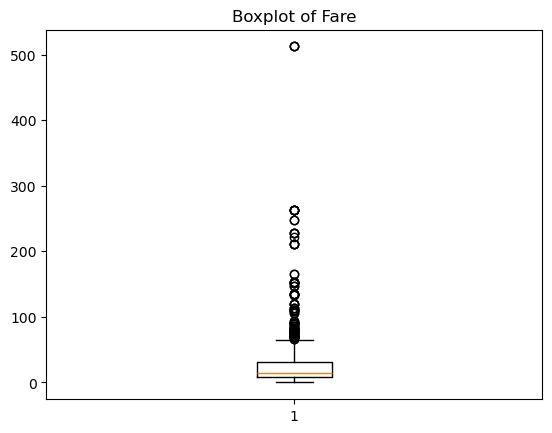

In [77]:
# detecting outliers

plt.boxplot(df["Fare"])
plt.title("Boxplot of Fare")
plt.show()

In [78]:
# encoding categorical data 

encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

In [79]:
# encode embarked data

df["Embarked"] = encoder.fit_transform(df["Embarked"])

In [80]:
# Normalise Numerical data (Age column)

scaler = MinMaxScaler()

df[["Age"]] = scaler.fit_transform(df[["Age"]])

In [81]:
# standartise the fare column

standard = StandardScaler()

df[["Fare"]] = standard.fit_transform(df[["Fare"]])

In [82]:
# displaying processed data

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,0.271174,1,0,A/5 21171,-0.502445,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,0.472229,1,0,PC 17599,0.786845,0
2,3,1,3,"Heikkinen, Miss. Laina",0,0.321438,0,0,STON/O2. 3101282,-0.488854,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,0.434531,1,0,113803,0.420730,2
4,5,0,3,"Allen, Mr. William Henry",1,0.434531,0,0,373450,-0.486337,2


In [83]:
# saving dataset

df.to_csv("processed_train.csv", index=False)